# NLP

# Text Classification and Sentiment Analysis

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [7]:
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [8]:
# nltk resources
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vchin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\vchin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vchin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\vchin\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\vchin\AppData\Roaming\nltk_data...


True

In [9]:
# load dataset
df=pd.read_csv('amazonreviews.tsv',sep='\t')
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [10]:
df.shape

(10000, 2)

In [11]:
df.columns

Index(['label', 'review'], dtype='object')

In [12]:
df.dtypes

label     object
review    object
dtype: object

In [13]:
# missing values
df.isnull().sum()

label     0
review    0
dtype: int64

In [14]:
# duplicate rows
df.duplicated().sum()

np.int64(0)

In [15]:
print('Sentiment Distribution:')
print(df['label'].value_counts())

Sentiment Distribution:
label
neg    5097
pos    4903
Name: count, dtype: int64


In [16]:
# Data Cleaning
df=df.drop_duplicates()

In [17]:
df=df.dropna(subset=['review'])

In [18]:
df=df.reset_index(drop=True)

In [19]:
df['review']=df['review'].str.lower()

In [20]:
# remove stopwords and special characters
stop_words=set(stopwords.words('english'))
def clean_text(text):
    words=word_tokenize(text)
    words=[
        word for word in words
        if word.isalpha() and word not in stop_words
    ]
    return ' '.join(words)
df['clean_review']=df['review'].apply(clean_text)

In [21]:
df[["label", "review", "clean_review"]].head()

,label,review,clean_review
0,pos,stuning even for the non-gamer: this sound tra...,stuning even sound track beautiful paints sene...
1,pos,the best soundtrack ever to anything.: i'm rea...,best soundtrack ever anything reading lot revi...
2,pos,amazing!: this soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,pos,excellent soundtrack: i truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,pos,"remember, pull your jaw off the floor after he...",remember pull jaw floor hearing played game kn...


In [22]:
# Lemmatization
lemmatizer = WordNetLemmatizer()
def lemmatize_text(text):
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)
df["clean_review"] = df["clean_review"].apply(lemmatize_text)

In [23]:
df[['label','clean_review']].head()

,label,clean_review
0,pos,stuning even sound track beautiful paint sener...
1,pos,best soundtrack ever anything reading lot revi...
2,pos,amazing soundtrack favorite music time hand in...
3,pos,excellent soundtrack truly like soundtrack enj...
4,pos,remember pull jaw floor hearing played game kn...


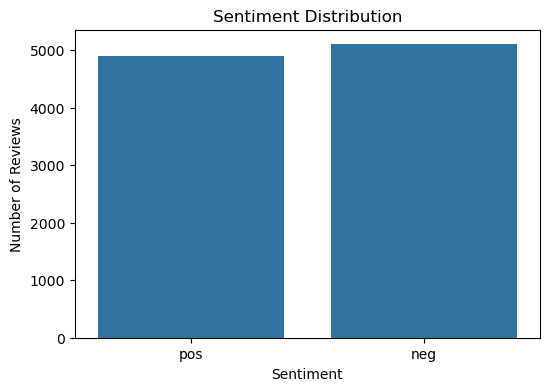

In [24]:
# sentiment distribution
plt.figure(figsize=(6,4))
sns.countplot(x='label',data=df)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

In [25]:
# seperate postive and negative reviews
positive_reviews = df[df["label"] == "pos"]["clean_review"]
negative_reviews = df[df["label"] == "neg"]["clean_review"]
positive_text = " ".join(positive_reviews)
negative_text = " ".join(negative_reviews)

Defaulting to user installation because normal site-packages is not writeable


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


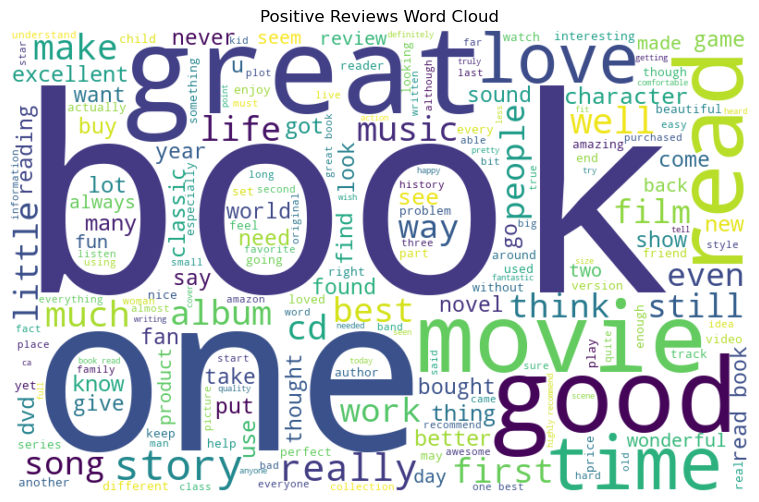

In [29]:
! pip install wordcloud
from wordcloud import WordCloud
# postive word cloud
positive_wordcloud = WordCloud(width=800,height=500,background_color="white").generate(positive_text)
plt.figure(figsize=(10, 6))
plt.imshow(positive_wordcloud,interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()

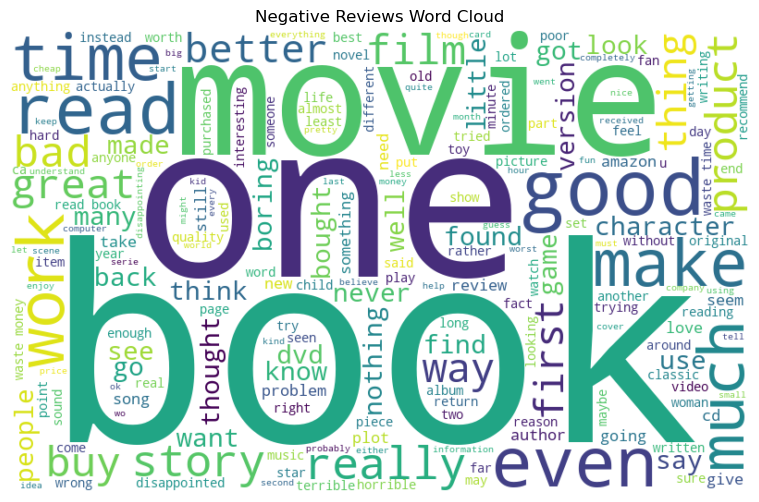

In [30]:
# negative word cloud
negative_wordcloud = WordCloud(width=800,height=500,background_color="white").generate(negative_text)
plt.figure(figsize=(10, 6))
plt.imshow(negative_wordcloud,interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()

In [33]:
from collections import Counter

In [34]:
# most common positive words
positive_words = positive_text.split()
positive_counter = Counter(positive_words)
print("Top 20 Positive Words:\n")
for word, count in positive_counter.most_common(20):
    print(word, ":", count)

Top 20 Positive Words:

book : 3884
great : 2104
one : 1944
good : 1648
read : 1584
like : 1327
movie : 1301
time : 1149
love : 1040
would : 1002
get : 940
story : 863
well : 856
really : 829
best : 805
first : 711
make : 705
work : 684
year : 671
much : 653


In [35]:
# most common negative words
negative_words = negative_text.split()
negative_counter = Counter(negative_words)
print("Top 20 Negative Words:\n")
for word, count in negative_counter.most_common(20):
    print(word, ":", count)

Top 20 Negative Words:

book : 3704
one : 2132
movie : 1751
would : 1600
like : 1576
get : 1292
time : 1285
read : 1247
good : 1147
even : 904
could : 880
buy : 824
really : 782
much : 773
work : 769
make : 764
story : 759
bad : 753
money : 751
first : 744


In [36]:
# define input and target
X=df['clean_review']
y=df['label']
print('Input Data:')
print(X.head())
print('\nTarget data:')
print(y.head())

Input Data:
0    stuning even sound track beautiful paint sener...
1    best soundtrack ever anything reading lot revi...
2    amazing soundtrack favorite music time hand in...
3    excellent soundtrack truly like soundtrack enj...
4    remember pull jaw floor hearing played game kn...
Name: clean_review, dtype: object

Target data:
0    pos
1    pos
2    pos
3    pos
4    pos
Name: label, dtype: object


In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 8000
Testing data: 2000


In [38]:
# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000,ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (8000, 5000)
Testing TF-IDF shape: (2000, 5000)


In [39]:
# Build Logistic Regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)
print("Model training completed successfully.")

Model training completed successfully.


In [40]:
# make predictions
y_pred = model.predict(X_test_tfidf)
print("Predictions completed successfully.")
print(y_pred[:20])

Predictions completed successfully.
['neg' 'pos' 'neg' 'pos' 'neg' 'neg' 'neg' 'pos' 'pos' 'pos' 'neg' 'neg'
 'neg' 'neg' 'pos' 'pos' 'neg' 'pos' 'neg' 'neg']


In [41]:
# calculating accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8455
Accuracy (%): 84.55


In [42]:
# calculating F1-Score
from sklearn.metrics import f1_score
f1 = f1_score(y_test,y_pred,pos_label="pos")
print("F1-Score:", f1)

F1-Score: 0.8430675469781616


In [43]:
# classification Report
from sklearn.metrics import classification_report
print("Classification Report:\n")
print(classification_report(y_test,y_pred))

Classification Report:

              precision    recall  f1-score   support

         neg       0.85      0.84      0.85      1019
         pos       0.84      0.85      0.84       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



In [44]:
# confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred,labels=["neg", "pos"])
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[861 158]
 [151 830]]


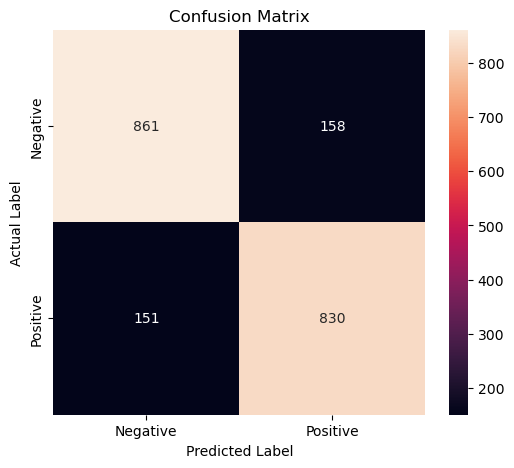

In [45]:
# visualization
plt.figure(figsize=(6, 5))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=["Negative", "Positive"],yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()